Import

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.signal import butter, freqz
from scipy.signal import filtfilt

Loading files and data

In [3]:
#Path of the file to open
path_left_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1D48140076_(2025-04-16)-IMU_Adele_13h48_15h18.csv" #ADELE
path_right_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1H46190449_(2025-04-16)-IMU_Adele_13h48_15h18.csv"#ADELE


#For pieces of files that were cut with "Cut_files.py"
data_left_wrist = pd.read_csv(path_left_wrist, header = 0, usecols = ['Timestamp','Accelerometer X','Accelerometer Y','Accelerometer Z'])
data_right_wrist = pd.read_csv(path_right_wrist, header = 0, usecols = ['Timestamp','Accelerometer X', 'Accelerometer Y', 'Accelerometer Z'])

# Saving the different sensor data
signal = {"left sensor" : [], 
          "right sensor" : []}

#Left wrist
#Convertion of the str data into float
for data_idx in range(len(data_left_wrist)) : 
        #Convertion of commas to dots to allow convertion of str data to float data
        data_left_wrist.loc[data_idx, "Accelerometer X"] = float(data_left_wrist.loc[data_idx, "Accelerometer X"].replace(",","."))
        data_left_wrist.loc[data_idx, "Accelerometer Y"] = float(data_left_wrist.loc[data_idx, "Accelerometer Y"].replace(",","."))
        data_left_wrist.loc[data_idx, "Accelerometer Z"] = float(data_left_wrist.loc[data_idx, "Accelerometer Z"].replace(",","."))- 0.981 # -0.981 removes the gravaity factor

        #Saving the activity count for each 0.01s signal
        #Magnitude vector for each 0.01s epoch
        norm = np.sqrt(data_left_wrist['Accelerometer X'][data_idx]**2 + data_left_wrist['Accelerometer Y'][data_idx]**2 + data_left_wrist['Accelerometer Z'][data_idx]**2)
        #Saving the norm in the database
        signal["left sensor"].append(norm)

#Right wrist
#Convertion of the str data into float
for data_idx in range(len(data_right_wrist)) : 
        #Convertion of commas to dots to allow convertion of str data to float data
        data_right_wrist.loc[data_idx, "Accelerometer X"] = float(data_right_wrist.loc[data_idx, "Accelerometer X"].replace(",","."))
        data_right_wrist.loc[data_idx, "Accelerometer Y"] = float(data_right_wrist.loc[data_idx, "Accelerometer Y"].replace(",","."))
        data_right_wrist.loc[data_idx, "Accelerometer Z"] = float(data_right_wrist.loc[data_idx, "Accelerometer Z"].replace(",",".")) - 0.981 # -0.981 removes the gravity factor

        #Saving the activity count for each 0.01s signal
        #Magnitude vector for each 0.01s epoch
        norm = np.sqrt(data_right_wrist['Accelerometer X'][data_idx]**2 + data_right_wrist['Accelerometer Y'][data_idx]**2 + data_right_wrist['Accelerometer Z'][data_idx]**2)
        #Saving the norm in the database
        signal["right sensor"].append(norm)

#List of the differents sensors to separate data from left [0] and right [1] wrist sensor
lst_sensors = [data_left_wrist, data_right_wrist]


Compression with np.sum() and np.reshape() (after zero padding)

[68.25490501 65.94175688 68.84173231 72.31320638 98.63211459 84.80788296
 64.55814331 63.73206338 65.86880518 68.76974824]


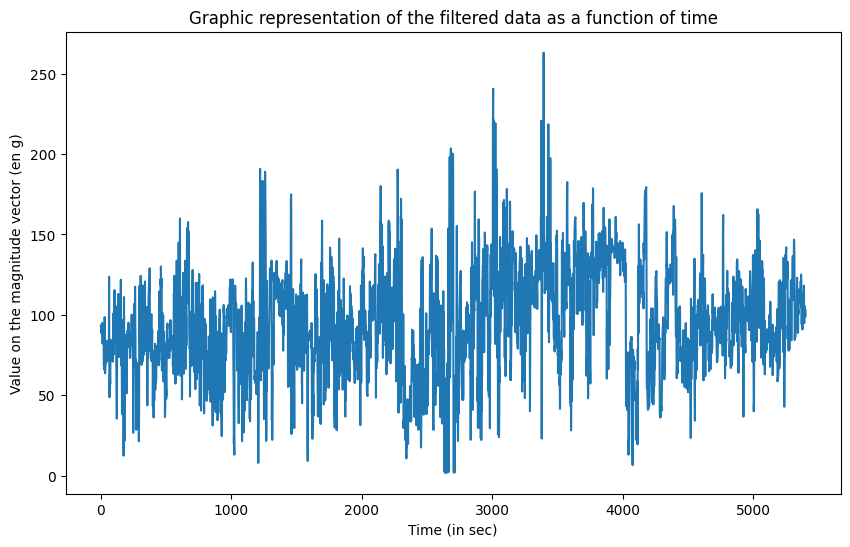

In [8]:
#Zero padding to allow the reshaping
signal_len = len(signal["left sensor"])
to_complete = signal_len % 10
if to_complete != 0:
    padding = 10 - to_complete
    padded_signal = np.pad(signal["left sensor"], (0, padding), mode='constant')
else:
    padded_signal_ = signal["left sensor"]

# Reshape in 100 samples epoch (1s epoch)
reshaped_signal = padded_signal.reshape(-1, 100)

# Sum of the magnitude vector for every 1s epoch = activity count
compression_np = np.sum(reshaped_signal, axis=1)

print(compression_np[25:35])

#Display
x_axis_time = np.arange(len(compression_np))
plt.figure(figsize=(10, 6))
plt.plot(x_axis_time, compression_np)
plt.xlabel("Time (in sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"Graphic representation of the filtered data as a function of time")   
plt.show()



Compression with pd.resample() (mieux pour des signaux temporels)

In [ ]:
# Créer une série temporelle avec un index à 100 Hz
# Chaque échantillon est espacé de 10 ms (0.01s)
index = pd.date_range(start=data_left_wrist["Timestamp"][0], periods=len(signal["left sensor"]), freq="10L")  # 'L' = milliseconds

series = pd.Series(signal["left sensor"], index=index)

# Utiliser resample pour sommer tous les secondes (soit 100 points à 100 Hz)
compression_pd = series.resample("1000L").sum()

print(compression_pd[25:35])



C:\Users\BEaCHILD3\AppData\Local\Temp\ipykernel_1908\3384955846.py:3: FutureWarning: 'L' is deprecated and will be removed in a future version, please use 'ms' instead.
  index = pd.date_range(start=data_left_wrist["Timestamp"][0], periods=len(signal["left sensor"]), freq="10L")  # 'L' = milliseconds
C:\Users\BEaCHILD3\AppData\Local\Temp\ipykernel_1908\3384955846.py:8: FutureWarning: 'L' is deprecated and will be removed in a future version, please use 'ms' instead.
  compression_pd = series.resample("1000L").sum()


2025-04-15 13:48:25+00:00    68.295326
2025-04-15 13:48:26+00:00    65.969595
2025-04-15 13:48:27+00:00    68.774059
2025-04-15 13:48:28+00:00    72.308710
2025-04-15 13:48:29+00:00    98.291198
2025-04-15 13:48:30+00:00    85.227844
2025-04-15 13:48:31+00:00    64.572669
2025-04-15 13:48:32+00:00    63.730393
2025-04-15 13:48:33+00:00    65.840920
2025-04-15 13:48:34+00:00    68.750359
Freq: 1000ms, dtype: float64


Compression from scratch

In [22]:
"""Grouping by :
1. CALCULATE VM for each 0.01 period
2. GROUP 0.01S EPOCHS IN 1S EPOCH (sum of the VM)

--> Method in Peach article
"""


#Dictonary saving activity counts for left wrist sensor [0] and right wrist sensor [1]
activity_counts = []

#Dictonary saving mean activity counts for left wrist sensor [0] and right wrist sensor [1]
mean_activity_counts = []

lst_sensors = [data_left_wrist]

#Browse data from the various sensors
for sensor_data in lst_sensors:

    activity_count_idx = 0
    #Dictonary saving activity counts for the sensor_data (left for the first loop lap, right for the second loop lap)
    activity_counts_sensor = []
    #Variable storing acceleration intensity for a 1 sec epoch
    sum_norm = 0

    for data_idx in range(len(sensor_data)): 
        #Magnitude vector for each 0.01s epoch
        norm = np.sqrt(sensor_data['Accelerometer X'][data_idx]**2 + sensor_data['Accelerometer Y'][data_idx]**2 + sensor_data['Accelerometer Z'][data_idx]**2)
            
        #Group 10ms epoch in 1s epoch and save the sum of intensities
        if activity_count_idx < 100:
            sum_norm += norm
            activity_count_idx += 1
        else:
            #Update activity_counts
            activity_counts_sensor.append(sum_norm.item())
            activity_count_idx = 0
            sum_norm = 0
    
    activity_counts.append(activity_counts_sensor) 
    mean_activity_counts.append((np.mean(activity_counts_sensor)).item())

print("\n*** Left wrist ***")
print(f"Mean activity count 1s epoch : {mean_activity_counts[0]}")
print(f"Sampling of activity count : {activity_counts[0][25:35]}")



*** Left wrist ***
Mean activity count 1s epoch : 94.80612962239098
Sampling of activity count : [67.04199348860979, 66.57661102693433, 70.44178947930446, 73.42553300745405, 106.63188067541309, 72.49453054370714, 64.58916418562737, 63.705887638441794, 66.99068857415487, 69.278089142121]


In [1]:
print("********* Numpy *********")
print(compression_np[25:35])
print(f"Mean activity count 1s epoch : {np.mean(compression_np) }")

print("********* Panda *********")
print(compression_pd)
print(f"Mean activity count 1s epoch : {np.mean(compression_pd)}")

print("********* Scratch *********")
print(activity_counts[0][25:35])
print(f"Mean activity count 1s epoch : {mean_activity_counts[0]}")

********* Numpy *********


NameError: name 'compression_np' is not defined

Les 3 méthodes ont les mêmes activity counts moyens : 94.80816268316997 (numpy et pandas) et 94.80612962239098 (pour algo fait maison).

La méthode la plus précise semble être celle utilisant panda (découpe par intervalle de temps donc est plus fiable s'il manque de intervalles de temps)

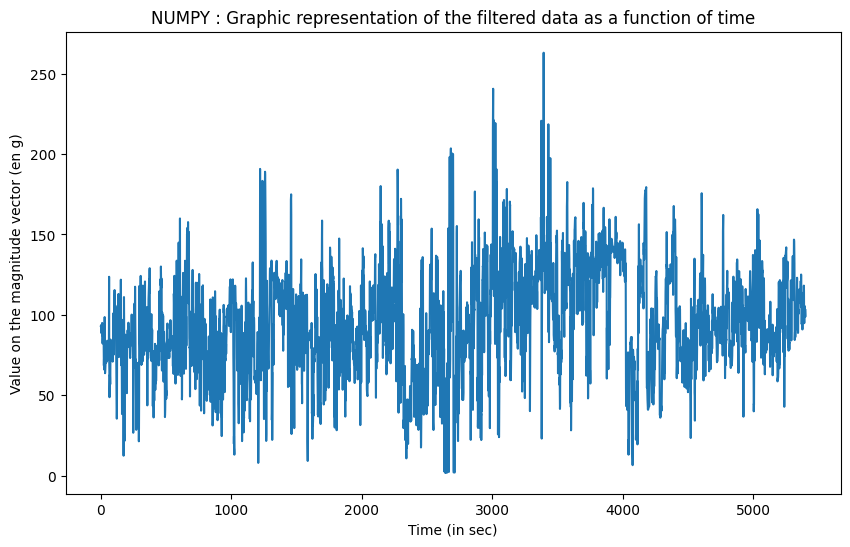

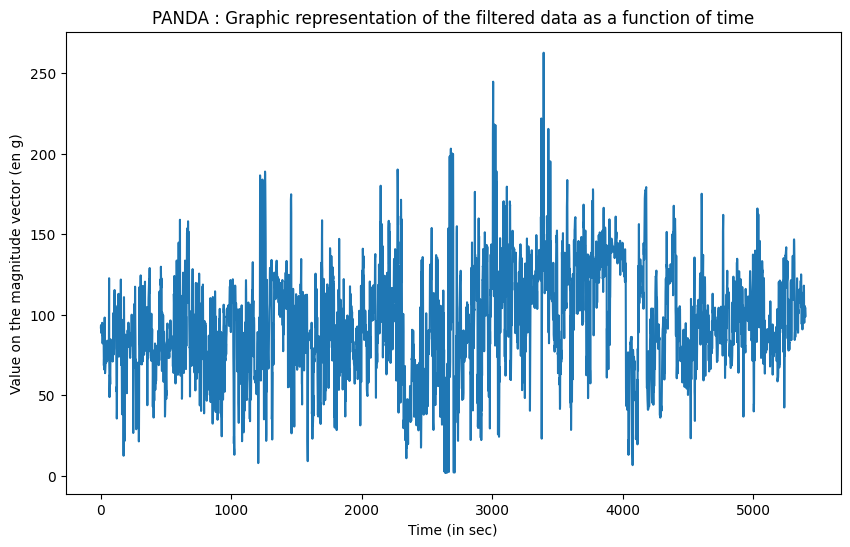

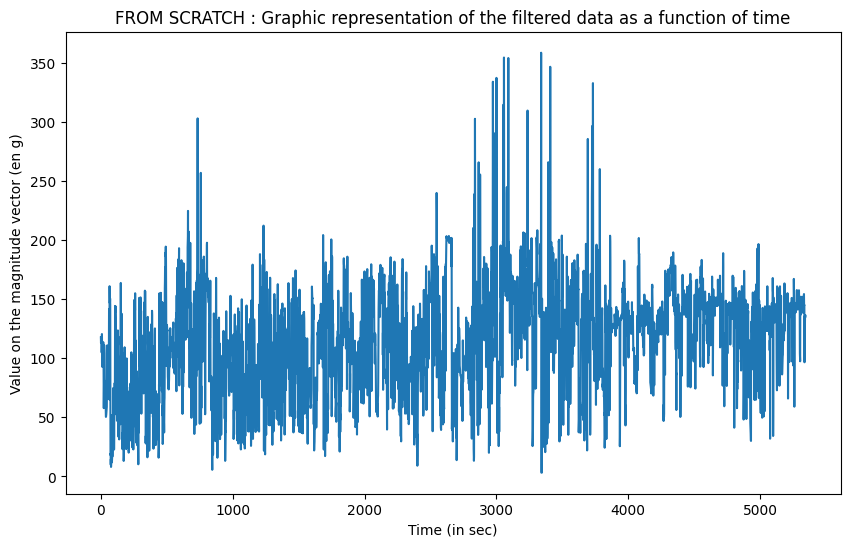

In [20]:
#Display
x_axis_time = np.arange(len(compression_np))
plt.figure(figsize=(10, 6))
plt.plot(x_axis_time, compression_np)
plt.xlabel("Time (in sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"NUMPY : Graphic representation of the filtered data as a function of time")   



#Display
x_axis_time = np.arange(len(compression_pd))
plt.figure(figsize=(10, 6))
plt.plot(x_axis_time, compression_pd)
plt.xlabel("Time (in sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"PANDA : Graphic representation of the filtered data as a function of time")   
 

#Display
x_axis_time = np.arange(len(activity_counts[0]))
plt.figure(figsize=(10, 6))
plt.plot(x_axis_time, activity_counts[0])
plt.xlabel("Time (in sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"FROM SCRATCH : Graphic representation of the filtered data as a function of time")   
plt.show()